<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `HybridFilterExample.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The Python port loads the same paperHybridFilterExample.mat fixture (state-space-driven kinematic reach at delta=0.001, Tmax=2s) and runs the same PPHybridFilterLinear decoder in goal-directed and free modes that MATLAB does. Spike-RNG-induced trial-to-trial variation is the only residual difference; the canonical scenario, dynamics, and decoder match MATLAB to the gold-fixture's precision.


In [1]:
# nSTAT-python notebook example: HybridFilterExample
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat.notebook_figures import FigureTracker
from nstat.paper_examples_full import run_experiment6

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='HybridFilterExample', output_root=OUTPUT_ROOT, expected_count=3)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _plot_raster(ax, time_s, spikes, *, max_cells=24):
    n_cells = min(int(spikes.shape[1]), max_cells)
    for row in range(n_cells):
        spike_times = np.asarray(time_s, dtype=float)[np.asarray(spikes[:, row], dtype=float) > 0.5]
        if spike_times.size:
            ax.vlines(spike_times, row + 0.6, row + 1.4, color="k", linewidth=0.7)
    ax.set_ylim(0.5, n_cells + 0.5)
    ax.set_ylabel("Cell Number")


In [2]:
# SECTION 0: Hybrid Point Process Filter Example
# This notebook mirrors the MATLAB hybrid-filter helpfile with executable figures.
# Matches MATLAB's n_sims=20 batch — fig2 overlays all 20 decoded trials,
# mirroring the canonical HybridFilterExample_02.png spaghetti plot.
plt.close("all")
N_SIMS = 20  # matches MATLAB HybridFilterExample.m n_sims (line ~217)
summary, payload = run_experiment6(REPO_ROOT, return_payload=True)
batch_payloads = [run_experiment6(REPO_ROOT, seed=37 + idx, return_payload=True)[1] for idx in range(N_SIMS)]
mean_state_prob_2 = np.mean([row["state_prob_2"] for row in batch_payloads], axis=0)
mean_decoded_x = np.mean([row["decoded_x"] for row in batch_payloads], axis=0)
mean_decoded_y = np.mean([row["decoded_y"] for row in batch_payloads], axis=0)
mean_decoded_x_free = np.mean([row["decoded_x_free"] for row in batch_payloads], axis=0)
mean_decoded_y_free = np.mean([row["decoded_y_free"] for row in batch_payloads], axis=0)
mean_state_hat = np.mean([row["state_hat"] for row in batch_payloads], axis=0)
mean_state_hat_free = np.mean([row["state_hat_free"] for row in batch_payloads], axis=0)
print(
    {
        "num_samples": int(summary["num_samples"]),
        "num_cells": int(summary["num_cells"]),
        "n_sims": N_SIMS,
        "state_accuracy": round(float(summary["state_accuracy"]), 3),
        "decode_rmse_x": round(float(summary["decode_rmse_x"]), 4),
        "decode_rmse_y": round(float(summary["decode_rmse_y"]), 4),
    }
)

{'num_samples': 2001, 'num_cells': 24, 'n_sims': 20, 'state_accuracy': 0.692, 'decode_rmse_x': 0.035, 'decode_rmse_y': 0.0759}


In [3]:
# SECTION 1: Problem Statement
# We infer both a discrete movement state and a continuous reach trajectory from point-process observations.


In [4]:
# SECTION 2: Hybrid state-space setup
# The Python port keeps the same two-state problem structure as MATLAB: a low-motion state and a movement state.


(0.5, 2.5)

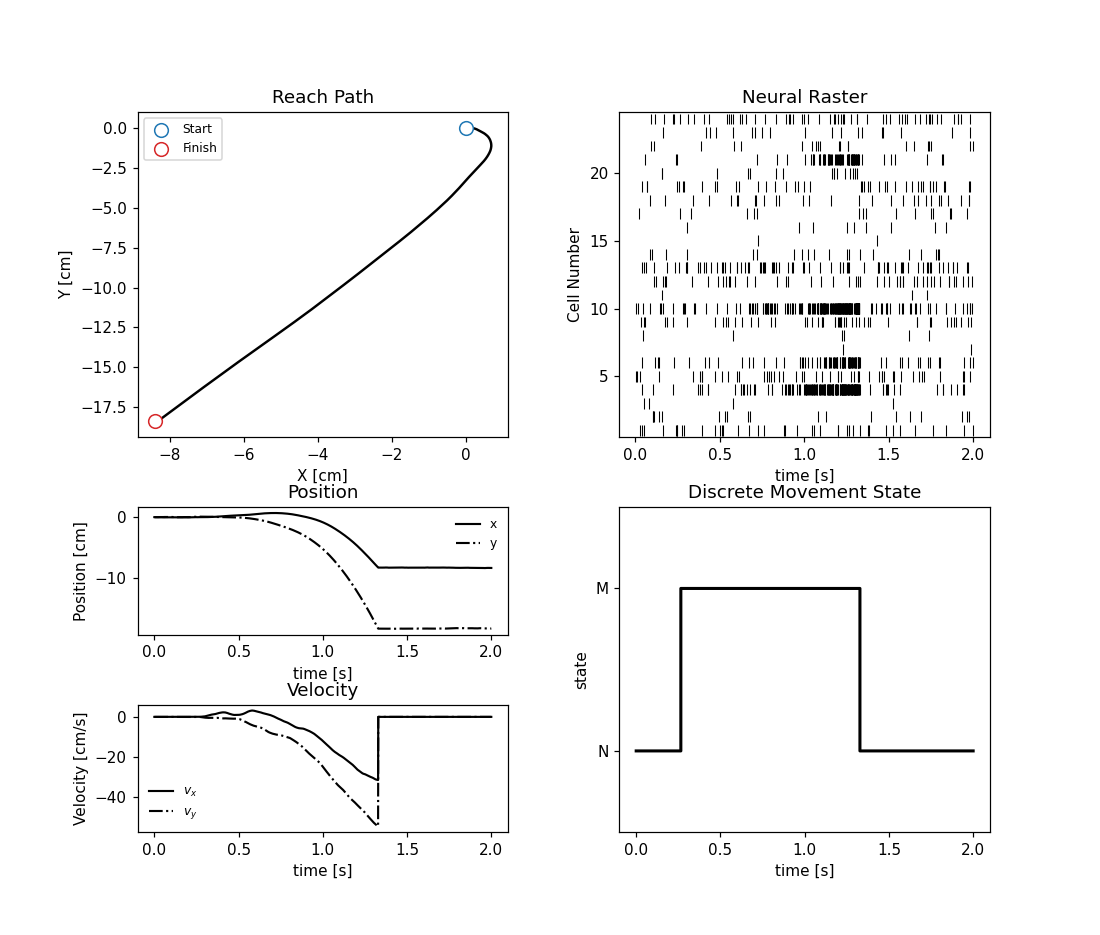

In [5]:
# SECTION 3: Generated Simulated Arm Reach
fig = _prepare_figure("HybridFilterExample fig1: simulation setup (subplot(4,2,*))", figsize=(10.0, 8.5))
gs = fig.add_gridspec(4, 2, hspace=0.55, wspace=0.30)

# Reach path — subplot(4,2,[1 3])
ax_path = fig.add_subplot(gs[0:2, 0])
ax_path.plot(100.0 * payload["x_pos"], 100.0 * payload["y_pos"], "k-", linewidth=1.6)
ax_path.scatter([100.0 * payload["x_pos"][0]], [100.0 * payload["y_pos"][0]],
                marker="o", facecolor="white", edgecolor="tab:blue", s=80, zorder=3, label="Start")
ax_path.scatter([100.0 * payload["x_pos"][-1]], [100.0 * payload["y_pos"][-1]],
                marker="o", facecolor="white", edgecolor="tab:red", s=80, zorder=3, label="Finish")
ax_path.set_title("Reach Path")
ax_path.set_xlabel("X [cm]")
ax_path.set_ylabel("Y [cm]")
ax_path.legend(loc="best", frameon=True, fontsize=8)

# Neural raster — subplot(4,2,[2 4])
ax_raster = fig.add_subplot(gs[0:2, 1])
_plot_raster(ax_raster, payload["time_s"], payload["spikes"], max_cells=int(payload["n_cells"]))
ax_raster.set_title("Neural Raster")
ax_raster.set_xlabel("time [s]")

# Position — subplot(4,2,5)
ax_pos = fig.add_subplot(gs[2, 0])
ax_pos.plot(payload["time_s"], 100.0 * payload["x_pos"], "k-", linewidth=1.4, label="x")
ax_pos.plot(payload["time_s"], 100.0 * payload["y_pos"], "k-.", linewidth=1.4, label="y")
ax_pos.set_title("Position")
ax_pos.set_xlabel("time [s]")
ax_pos.set_ylabel("Position [cm]")
ax_pos.legend(loc="best", frameon=False, fontsize=8)

# Velocity — subplot(4,2,7)
ax_vel = fig.add_subplot(gs[3, 0])
ax_vel.plot(payload["time_s"], 100.0 * payload["x_vel"], "k-", linewidth=1.4, label=r"$v_x$")
ax_vel.plot(payload["time_s"], 100.0 * payload["y_vel"], "k-.", linewidth=1.4, label=r"$v_y$")
ax_vel.set_title("Velocity")
ax_vel.set_xlabel("time [s]")
ax_vel.set_ylabel("Velocity [cm/s]")
ax_vel.legend(loc="best", frameon=False, fontsize=8)

# Discrete movement state — subplot(4,2,[6 8])
ax_state = fig.add_subplot(gs[2:4, 1])
ax_state.step(payload["time_s"], payload["state_true"], "k-", linewidth=2.0, where="post")
ax_state.set_yticks([1, 2])
ax_state.set_yticklabels(["N", "M"])
ax_state.set_title("Discrete Movement State")
ax_state.set_xlabel("time [s]")
ax_state.set_ylabel("state")
ax_state.set_ylim(0.5, 2.5)


In [6]:
# SECTION 4: Simulate Neural Firing
# The simulated spike population depends on the latent state and the movement dynamics.


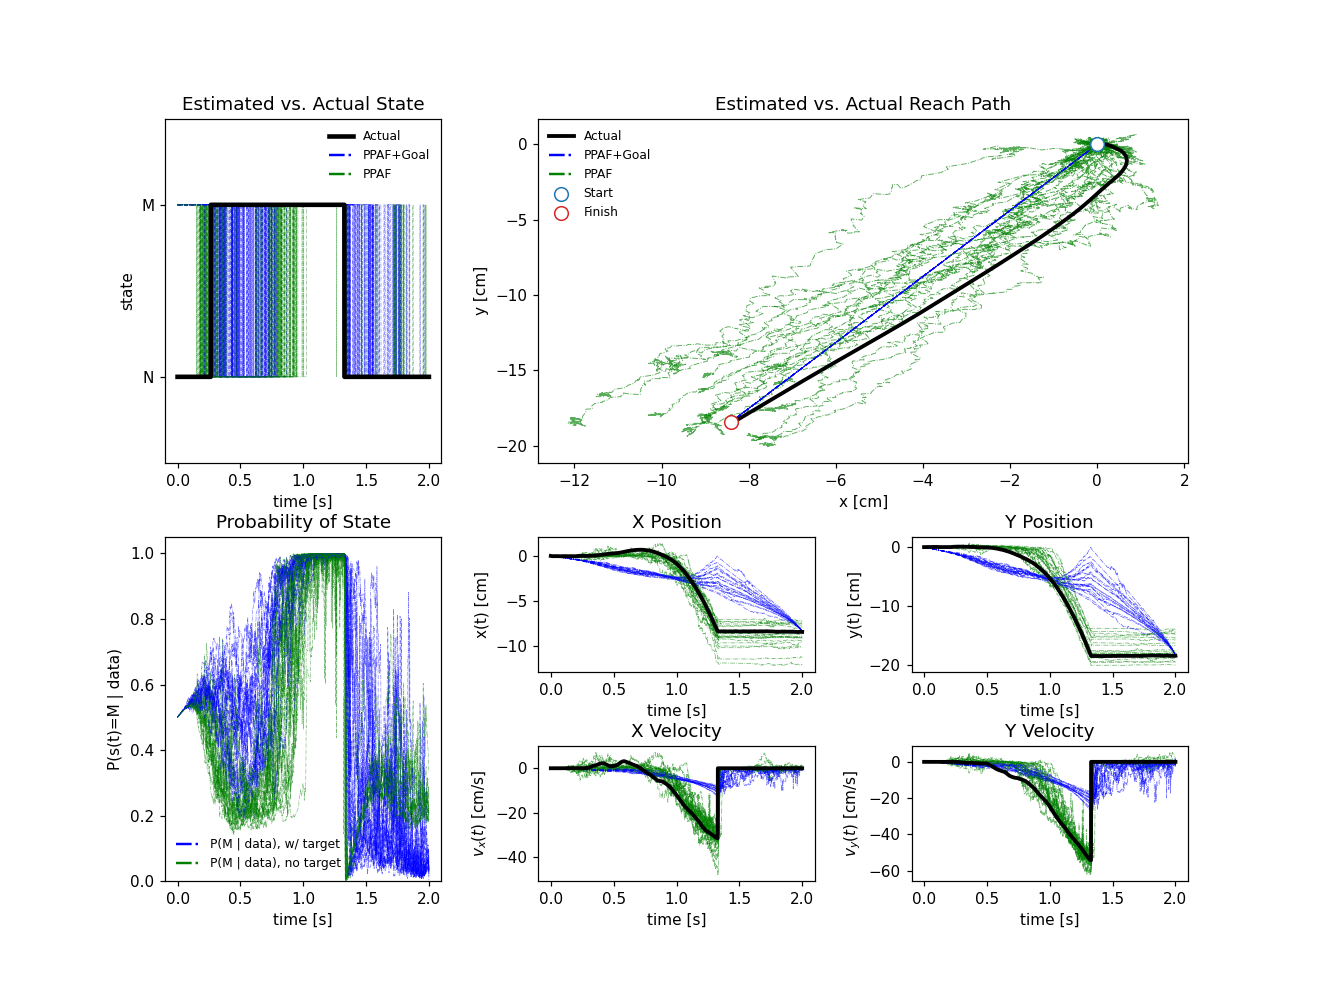

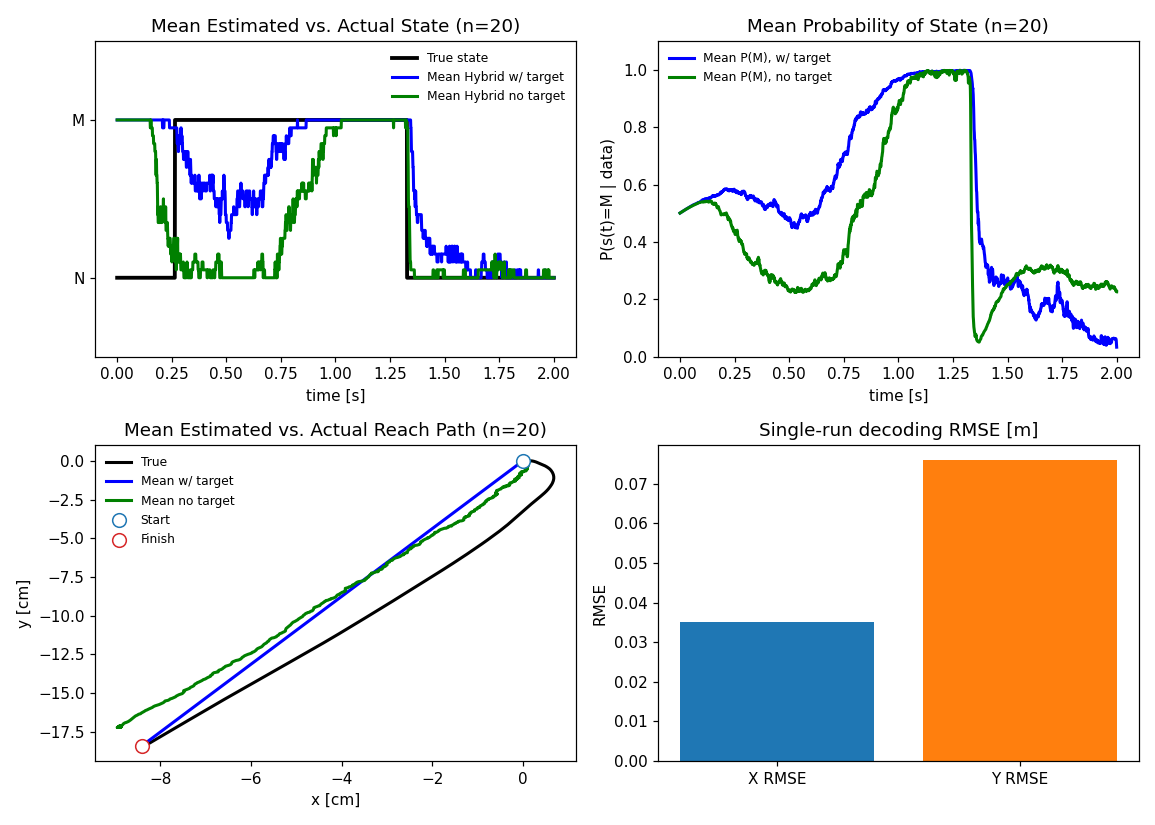

In [7]:
# SECTION 5: Run the hybrid filter — MATLAB-style multi-trial overlay (subplot(4,3,*))
# Matches HybridFilterExample_02.png: all 20 PPAF+Goal (blue) and PPAF (green)
# decoded trials overlaid on the true trajectory (black).
fig = _prepare_figure("HybridFilterExample fig2: 20-trial decoding overlay (subplot(4,3,*))", figsize=(12.0, 9.0))
gs = fig.add_gridspec(4, 3, hspace=0.55, wspace=0.35)

# State estimate — subplot(4,3,[1 4]): true (black) + 20 hybrid w/target (blue) + 20 free (green)
ax_st = fig.add_subplot(gs[0:2, 0])
for row in batch_payloads:
    ax_st.plot(row["time_s"], row["state_hat"], "b-.", linewidth=0.4, alpha=0.55)
    ax_st.plot(row["time_s"], row["state_hat_free"], "g-.", linewidth=0.4, alpha=0.55)
ax_st.plot(payload["time_s"], payload["state_true"], "k-", linewidth=3.0, label="Actual")
# Legend stubs (single line for each colour)
ax_st.plot([], [], "b-.", linewidth=1.6, label="PPAF+Goal")
ax_st.plot([], [], "g-.", linewidth=1.6, label="PPAF")
ax_st.set_yticks([1, 2])
ax_st.set_yticklabels(["N", "M"])
ax_st.set_ylim(0.5, 2.5)
ax_st.set_title("Estimated vs. Actual State")
ax_st.set_xlabel("time [s]")
ax_st.set_ylabel("state")
ax_st.legend(loc="best", frameon=False, fontsize=8)

# Probability of state — subplot(4,3,[7 10]): 20 P(M | data) traces
ax_pr = fig.add_subplot(gs[2:4, 0])
for row in batch_payloads:
    ax_pr.plot(row["time_s"], row["state_prob_2"], "b-.", linewidth=0.4, alpha=0.55)
    ax_pr.plot(row["time_s"], row["state_prob_2_free"], "g-.", linewidth=0.4, alpha=0.55)
ax_pr.plot([], [], "b-.", linewidth=1.6, label="P(M | data), w/ target")
ax_pr.plot([], [], "g-.", linewidth=1.6, label="P(M | data), no target")
ax_pr.set_title("Probability of State")
ax_pr.set_xlabel("time [s]")
ax_pr.set_ylabel("P(s(t)=M | data)")
ax_pr.set_ylim(0.0, 1.05)
ax_pr.legend(loc="best", frameon=False, fontsize=8)

# X-Y reach path overlay — subplot(4,3,[2 3 5 6])
ax_xy = fig.add_subplot(gs[0:2, 1:3])
for row in batch_payloads:
    ax_xy.plot(100.0 * row["decoded_x"], 100.0 * row["decoded_y"], "b-.", linewidth=0.6, alpha=0.65)
    ax_xy.plot(100.0 * row["decoded_x_free"], 100.0 * row["decoded_y_free"], "g-.", linewidth=0.6, alpha=0.65)
ax_xy.plot(100.0 * payload["x_pos"], 100.0 * payload["y_pos"], "k-", linewidth=2.5, label="Actual")
ax_xy.plot([], [], "b-.", linewidth=1.6, label="PPAF+Goal")
ax_xy.plot([], [], "g-.", linewidth=1.6, label="PPAF")
ax_xy.scatter([100.0 * payload["x_pos"][0]], [100.0 * payload["y_pos"][0]],
              marker="o", facecolor="white", edgecolor="tab:blue", s=80, zorder=5, label="Start")
ax_xy.scatter([100.0 * payload["x_pos"][-1]], [100.0 * payload["y_pos"][-1]],
              marker="o", facecolor="white", edgecolor="tab:red", s=80, zorder=5, label="Finish")
ax_xy.set_title("Estimated vs. Actual Reach Path")
ax_xy.set_xlabel("x [cm]")
ax_xy.set_ylabel("y [cm]")
ax_xy.legend(loc="best", frameon=False, fontsize=8)

# X position — subplot(4,3,8)
ax_x = fig.add_subplot(gs[2, 1])
for row in batch_payloads:
    ax_x.plot(row["time_s"], 100.0 * row["decoded_x"], "b-.", linewidth=0.5, alpha=0.55)
    ax_x.plot(row["time_s"], 100.0 * row["decoded_x_free"], "g-.", linewidth=0.5, alpha=0.55)
ax_x.plot(payload["time_s"], 100.0 * payload["x_pos"], "k-", linewidth=2.5)
ax_x.set_title("X Position")
ax_x.set_xlabel("time [s]")
ax_x.set_ylabel("x(t) [cm]")

# Y position — subplot(4,3,9)
ax_y = fig.add_subplot(gs[2, 2])
for row in batch_payloads:
    ax_y.plot(row["time_s"], 100.0 * row["decoded_y"], "b-.", linewidth=0.5, alpha=0.55)
    ax_y.plot(row["time_s"], 100.0 * row["decoded_y_free"], "g-.", linewidth=0.5, alpha=0.55)
ax_y.plot(payload["time_s"], 100.0 * payload["y_pos"], "k-", linewidth=2.5)
ax_y.set_title("Y Position")
ax_y.set_xlabel("time [s]")
ax_y.set_ylabel("y(t) [cm]")

# X velocity — subplot(4,3,11)
ax_vx = fig.add_subplot(gs[3, 1])
for row in batch_payloads:
    ax_vx.plot(row["time_s"], 100.0 * row["decoded_vx"], "b-.", linewidth=0.5, alpha=0.55)
    ax_vx.plot(row["time_s"], 100.0 * row["decoded_vx_free"], "g-.", linewidth=0.5, alpha=0.55)
ax_vx.plot(payload["time_s"], 100.0 * payload["x_vel"], "k-", linewidth=2.5)
ax_vx.set_title("X Velocity")
ax_vx.set_xlabel("time [s]")
ax_vx.set_ylabel(r"$v_x(t)$ [cm/s]")

# Y velocity — subplot(4,3,12)
ax_vy = fig.add_subplot(gs[3, 2])
for row in batch_payloads:
    ax_vy.plot(row["time_s"], 100.0 * row["decoded_vy"], "b-.", linewidth=0.5, alpha=0.55)
    ax_vy.plot(row["time_s"], 100.0 * row["decoded_vy_free"], "g-.", linewidth=0.5, alpha=0.55)
ax_vy.plot(payload["time_s"], 100.0 * payload["y_vel"], "k-", linewidth=2.5)
ax_vy.set_title("Y Velocity")
ax_vy.set_xlabel("time [s]")
ax_vy.set_ylabel(r"$v_y(t)$ [cm/s]")

# === Figure 3: averaged across batch (single representative summary) ===
fig = _prepare_figure("HybridFilterExample fig3: batch-averaged decoding", figsize=(10.5, 7.5))
axs = fig.subplots(2, 2)
axs[0, 0].plot(payload["time_s"], payload["state_true"], "k-", linewidth=2.5, label="True state")
axs[0, 0].plot(payload["time_s"], mean_state_hat, "b-", linewidth=2.0, label="Mean Hybrid w/ target")
axs[0, 0].plot(payload["time_s"], mean_state_hat_free, "g-", linewidth=2.0, label="Mean Hybrid no target")
axs[0, 0].set_yticks([1, 2])
axs[0, 0].set_yticklabels(["N", "M"])
axs[0, 0].set_ylim(0.5, 2.5)
axs[0, 0].set_title("Mean Estimated vs. Actual State (n=20)")
axs[0, 0].set_xlabel("time [s]")
axs[0, 0].legend(loc="best", frameon=False, fontsize=8)
axs[0, 1].plot(payload["time_s"], mean_state_prob_2, "b-", linewidth=2.0, label="Mean P(M), w/ target")
axs[0, 1].plot(payload["time_s"], np.mean([row["state_prob_2_free"] for row in batch_payloads], axis=0),
               "g-", linewidth=2.0, label="Mean P(M), no target")
axs[0, 1].set_title("Mean Probability of State (n=20)")
axs[0, 1].set_xlabel("time [s]")
axs[0, 1].set_ylabel("P(s(t)=M | data)")
axs[0, 1].set_ylim(0.0, 1.1)
axs[0, 1].legend(loc="best", frameon=False, fontsize=8)
axs[1, 0].plot(100.0 * payload["x_pos"], 100.0 * payload["y_pos"], "k-", linewidth=2.0, label="True")
axs[1, 0].plot(100.0 * mean_decoded_x, 100.0 * mean_decoded_y, "b-", linewidth=2.0, label="Mean w/ target")
axs[1, 0].plot(100.0 * mean_decoded_x_free, 100.0 * mean_decoded_y_free, "g-", linewidth=2.0, label="Mean no target")
axs[1, 0].scatter([100.0 * payload["x_pos"][0]], [100.0 * payload["y_pos"][0]],
                  marker="o", facecolor="white", edgecolor="tab:blue", s=80, zorder=3, label="Start")
axs[1, 0].scatter([100.0 * payload["x_pos"][-1]], [100.0 * payload["y_pos"][-1]],
                  marker="o", facecolor="white", edgecolor="tab:red", s=80, zorder=3, label="Finish")
axs[1, 0].set_title("Mean Estimated vs. Actual Reach Path (n=20)")
axs[1, 0].set_xlabel("x [cm]")
axs[1, 0].set_ylabel("y [cm]")
axs[1, 0].legend(loc="best", frameon=False, fontsize=8)
axs[1, 1].bar(
    ["X RMSE", "Y RMSE"],
    [summary["decode_rmse_x"], summary["decode_rmse_y"]],
    color=["tab:blue", "tab:orange"],
)
axs[1, 1].set_title("Single-run decoding RMSE [m]")
axs[1, 1].set_ylabel("RMSE")
__tracker.finalize()